In [ ]:
import sys, os
if os.path.abspath('.') not in sys.path:
    sys.path.insert(0, os.path.abspath('.'))
if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, os.path.abspath('..'))
from env_setup import setup_env
setup_env()

# Deep Reinforcement Learning Laboratory

In this laboratory session we will work on getting more advanced versions of Deep Reinforcement Learning algorithms up and running. Deep Reinforcement Learning is **hard**, and getting agents to stably train can be frustrating and requires quite a bit of subtlety in analysis of intermediate results. We will start by refactoring (a bit) my implementation of `REINFORCE` on the [Cartpole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/). 

## Exercise 1: Improving my `REINFORCE` Implementation (warm up)

In this exercise we will refactor a bit and improve some aspects of my `REINFORCE` implementation. 

**First Things First**: Spend some time playing with the environment to make sure you understand how it works.

In [66]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Instantiate a rendering and a non-rendering environment.
env_render = gym.make('CartPole-v1', render_mode='human')
env = gym.make('CartPole-v1')
from tqdm import tqdm
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt
env = gym.make('CartPole-v1')


--- Exploratory Environment Analysis ---
Action Space: Discrete(2)
Observation Space Bounds: [-4.8               -inf -0.41887903        -inf] to [4.8               inf 0.41887903        inf]


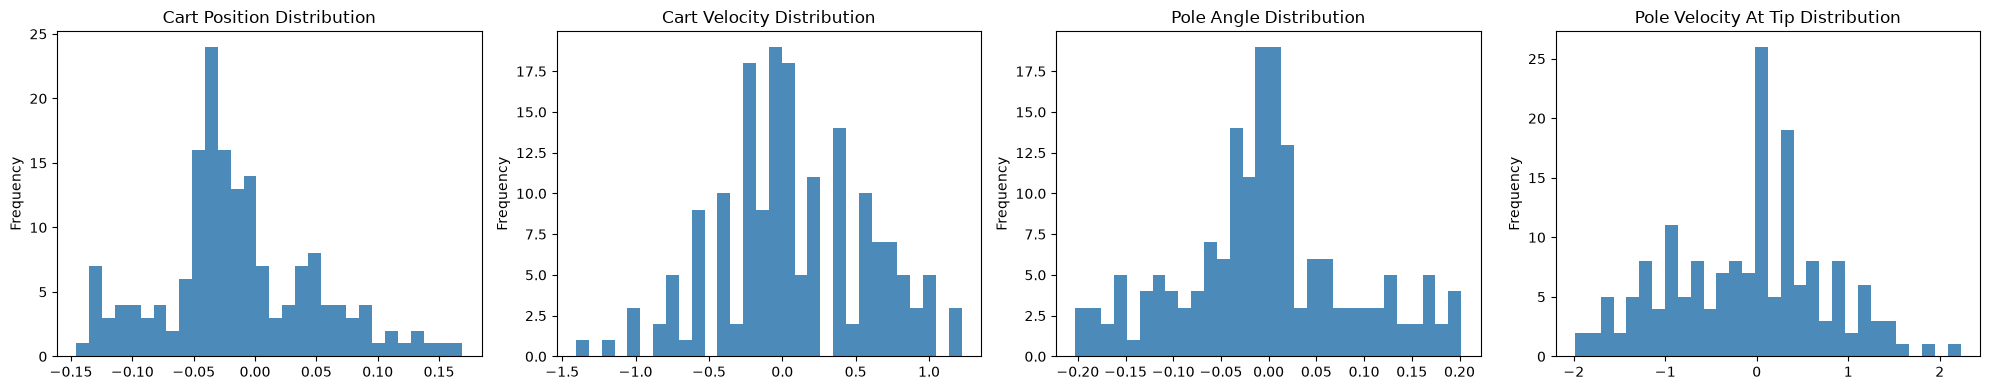

These histograms show the initial 'In-Distribution' state manifold our agent will experience before training!


In [67]:
# --- Exploratory Environment Analysis (EEA) ---
print("--- Exploratory Environment Analysis ---")

# 1. Action Space and Observation Space Bounds
print(f"Action Space: {env.action_space}")
print(f"Observation Space Bounds: {env.observation_space.low} to {env.observation_space.high}")

# 2. Collect Random Trajectories to analyze state distribution
random_states = []
for _ in range(10):  # Play 10 random episodes
    obs, info = env.reset()
    while True:
        random_states.append(obs)
        action = env.action_space.sample()
        obs, reward, term, trunc, info = env.step(action)
        if term or trunc:
            break

random_states = np.array(random_states)

# 3. Plot State Distribution Histograms
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
state_labels = ['Cart Position', 'Cart Velocity', 'Pole Angle', 'Pole Velocity At Tip']

for i in range(4):
    axes[i].hist(random_states[:, i], bins=30, color='#005A9C', alpha=0.7)
    axes[i].set_title(f"{state_labels[i]} Distribution")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("These histograms show the initial 'In-Distribution' state manifold our agent will experience before training!")



**Next Things Next**: Now get your `REINFORCE` implementation working on the environment. You can import my (probably buggy and definitely inefficient) implementation here. Or even better, refactor an implementation into a separate package from which you can `import` the stuff you need here. 

In [68]:
class PolicyNet(nn.Module):
    def __init__(self, env):
        super().__init__()
        self.fc1 = nn.Linear(env.observation_space.shape[0], 128)
        self.fc2 = nn.Linear(128, env.action_space.n)
        
    def forward(self, s):
        s = F.relu(self.fc1(s))
        s = F.softmax(self.fc2(s), dim=-1)
        return s

def select_action(env, obs, policy):
    dist = Categorical(policy(obs))
    action = dist.sample()
    log_prob = dist.log_prob(action)
    return action.item(), log_prob.unsqueeze(0)

def compute_returns(rewards, gamma):
    R = 0
    returns = []
    for r in reversed(rewards):
        R = r + gamma * R
        returns.append(R)
    return returns[::-1]

def run_episode(env, policy, maxlen=500):
    observations, actions, log_probs, rewards = [], [], [], []
    obs, info = env.reset()
    for _ in range(maxlen):
        obs = torch.tensor(obs, dtype=torch.float32)
        action, log_prob = select_action(env, obs, policy)
        observations.append(obs)
        actions.append(action)
        log_probs.append(log_prob)
        
        obs, reward, term, trunc, info = env.step(action)
        rewards.append(reward)
        if term or trunc:
            break
    return observations, actions, torch.cat(log_probs), rewards

def evaluate_agent(env, policy, num_episodes=5):
    policy.eval()
    total_rewards = []
    total_lengths = []
    with torch.no_grad():
        for _ in range(num_episodes):
            _, _, _, rewards = run_episode(env, policy)
            total_rewards.append(sum(rewards))
            total_lengths.append(len(rewards))
    policy.train()
    return np.mean(total_rewards), np.mean(total_lengths)

def reinforce(policy, env, gamma=0.99, num_episodes=500, standardize=True, eval_every_n=50, eval_episodes_m=5):
    opt = torch.optim.Adam(policy.parameters(), lr=1e-2)
    eval_rewards = []
    eval_lengths = []
    
    for episode in tqdm(range(num_episodes), desc="Training REINFORCE"):
        _, _, log_probs, rewards = run_episode(env, policy)
        returns = torch.tensor(compute_returns(rewards, gamma), dtype=torch.float32)
        
        if standardize:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)
            
        opt.zero_grad()
        loss = -(log_probs * returns).sum()
        loss.backward()
        opt.step()
        
        if (episode + 1) % eval_every_n == 0:
            avg_reward, avg_length = evaluate_agent(env, policy, num_episodes=eval_episodes_m)
            eval_rewards.append(avg_reward)
            eval_lengths.append(avg_length)
            if 'wandb' in globals() and wandb.run is not None:
                wandb.log({"eval_reward": avg_reward, "eval_length": avg_length, "episode": episode + 1})
            
    return eval_rewards, eval_lengths


**Last Things Last**: My implementation does a **super crappy** job of evaluating the agent performance during training. The running average is not a very good metric. Modify my implementation so that every $N$ iterations (make $N$ an argument to the training function) the agent is run for $M$ episodes in the environment. Collect and return: (1) The average **total** reward received over the $M$ iterations; and (2) the average episode length. Analyze the performance of your agents with these new metrics.

Training baseline REINFORCE with new metrics...


Training REINFORCE: 100%|████████████████████████████████████████████████████████████████| 500/500 [00:35<00:00, 14.07it/s]


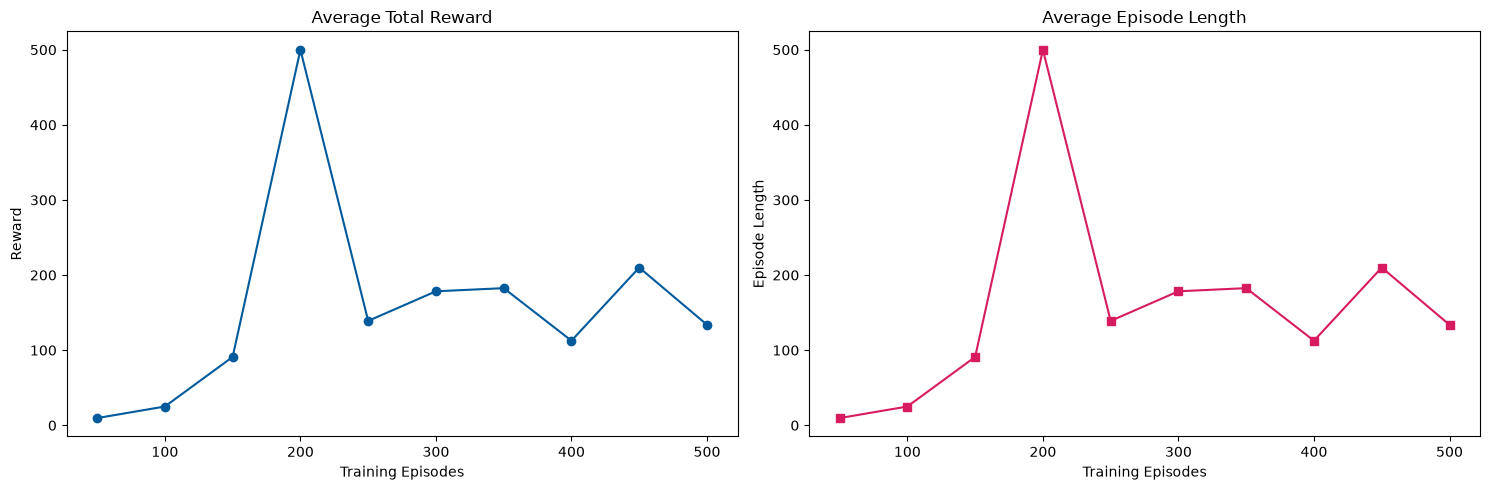

In [70]:
import wandb
wandb.init(project="DLA-Lab3", name="REINFORCE_Baseline", reinit=True)
print("Training baseline REINFORCE with new metrics...")
policy = PolicyNet(env)
eval_rewards_reinforce, eval_lengths_reinforce = reinforce(policy, env, standardize=True, eval_every_n=50, eval_episodes_m=5)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

eval_steps = range(50, 501, 50)

axes[0].plot(eval_steps, eval_rewards_reinforce, marker='o', color='#005A9C')
axes[0].set_title("Average Total Reward")
axes[0].set_xlabel("Training Episodes")
axes[0].set_ylabel("Reward")

axes[1].plot(eval_steps, eval_lengths_reinforce, marker='s', color='#D81B60')
axes[1].set_title("Average Episode Length")
axes[1].set_xlabel("Training Episodes")
axes[1].set_ylabel("Episode Length")

plt.tight_layout()
plt.show()


-----
## Exercise 2: `REINFORCE` with a Value Baseline (warm up)

In this exercise we will augment my implementation (or your own) of `REINFORCE` to subtract a baseline from the target in the update equation in order to stabilize (and hopefully speed-up) convergence. For now we will stick to the Cartpole environment.



**First Things First**: Recall from the slides on Deep Reinforcement Learning that we can **subtract** any function that doesn't depend on the current action from the q-value without changing the (maximum of our) objecttive function $J$:  

$$ \nabla J(\boldsymbol{\theta}) \propto \sum_{s} \mu(s) \sum_a \left( q_{\pi}(s, a) - b(s) \right) \nabla \pi(a \mid s, \boldsymbol{\theta}) $$

In `REINFORCE` this means we can subtract from our target $G_t$:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - b(S_t)) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

Since we are only interested in the **maximum** of our objective, we can also **rescale** our target by any function that also doesn't depend on the action. A **simple baseline** which is even independent of the state -- that is, it is **constant** for each episode -- is to just **standardize rewards within the episode**. So, we **subtract** the average return and **divide** by the variance of returns:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha \left(\frac{G_t - \bar{G}}{\sigma_G}\right) \nabla  \pi(A_t \mid s, \boldsymbol{\theta}) $$

This baseline is **already** implemented in my implementation of `REINFORCE`. Experiment with and without this standardization baseline and compare the performance. We are going to do something more interesting.

Training REINFORCE WITHOUT standardization baseline...


Training REINFORCE: 100%|████████████████████████████████████████████████████████████████| 500/500 [00:24<00:00, 20.27it/s]


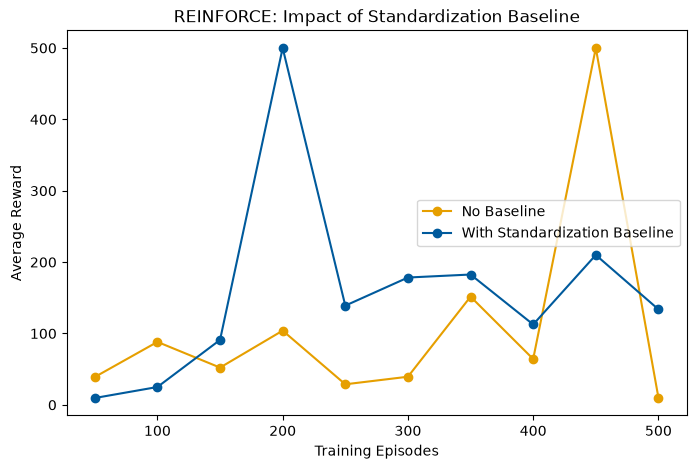

In [71]:
import wandb
wandb.init(project="DLA-Lab3", name="REINFORCE_NoStandardization", reinit=True)
print("Training REINFORCE WITHOUT standardization baseline...")
policy_no_baseline = PolicyNet(env)
eval_rewards_no_base, eval_lengths_no_base = reinforce(policy_no_baseline, env, standardize=False, eval_every_n=50, eval_episodes_m=5)

# Plot comparison
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
eval_steps = range(50, 501, 50)

ax.plot(eval_steps, eval_rewards_no_base, marker='o', color='#E69F00', label='No Baseline')
ax.plot(eval_steps, eval_rewards_reinforce, marker='o', color='#005A9C', label='With Standardization Baseline')
ax.set_title("REINFORCE: Impact of Standardization Baseline")
ax.set_xlabel("Training Episodes")
ax.set_ylabel("Average Reward")
ax.legend()
plt.show()


**The Real Exercise**: Standard practice is to use the state-value function $v(s)$ as a baseline. This is intuitively appealing -- we are more interested in updating out policy for returns that estimate the current **value** worse. Our new update becomes:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - \tilde{v}(S_t \mid \mathbf{w})) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

where $\tilde{v}(s \mid \mathbf{w})$ is a **deep neural network** with parameters $w$ that estimates $v_\pi(s)$. What neural network? Typically, we use the **same** network architecture as that of the Policy.

**Your Task**: Modify your implementation to fit a second, baseline network to estimate the value function and use it as **baseline**. 

In [72]:
class ValueNet(nn.Module):
    def __init__(self, env):
        super().__init__()
        # Same architecture as PolicyNet, but outputs 1 scalar value
        self.fc1 = nn.Linear(env.observation_space.shape[0], 128)
        self.fc2 = nn.Linear(128, 1)
        
    def forward(self, s):
        s = F.relu(self.fc1(s))
        return self.fc2(s)

def reinforce_with_baseline(policy, value_net, env, gamma=0.99, num_episodes=500, eval_every_n=50, eval_episodes_m=5):
    opt_policy = torch.optim.Adam(policy.parameters(), lr=1e-2)
    opt_value = torch.optim.Adam(value_net.parameters(), lr=1e-2)
    
    eval_rewards = []
    eval_lengths = []
    
    for episode in tqdm(range(num_episodes), desc="Training REINFORCE w/ Baseline"):
        observations, actions, log_probs, rewards = run_episode(env, policy)
        
        # Compute Monte Carlo Returns
        returns = torch.tensor(compute_returns(rewards, gamma), dtype=torch.float32)
        
        # Stack observations and pass through Value Network
        obs_tensor = torch.stack(observations)
        values = value_net(obs_tensor).squeeze()
        
        # Compute Advantage (A_t = G_t - V(S_t))
        # Detach values for the policy update so gradients don't flow into the value net from the policy loss
        advantages = returns - values.detach()
        
        # Standardize Advantages to further stabilize training
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        # Policy Loss
        policy_loss = -(log_probs * advantages).sum()
        
        # Value Loss (MSE between predicted values and actual returns)
        value_loss = F.mse_loss(values, returns)
        
        # Update Policy Network
        opt_policy.zero_grad()
        policy_loss.backward()
        opt_policy.step()
        
        # Update Value Network
        opt_value.zero_grad()
        value_loss.backward()
        opt_value.step()
        
        if (episode + 1) % eval_every_n == 0:
            avg_reward, avg_length = evaluate_agent(env, policy, num_episodes=eval_episodes_m)
            eval_rewards.append(avg_reward)
            eval_lengths.append(avg_length)
            if 'wandb' in globals() and wandb.run is not None:
                wandb.log({"eval_reward": avg_reward, "eval_length": avg_length, "episode": episode + 1})
            
    return eval_rewards, eval_lengths

Training REINFORCE WITH Neural Value Baseline...


Training REINFORCE w/ Baseline: 100%|████████████████████████████████████████████████████| 500/500 [01:07<00:00,  7.44it/s]


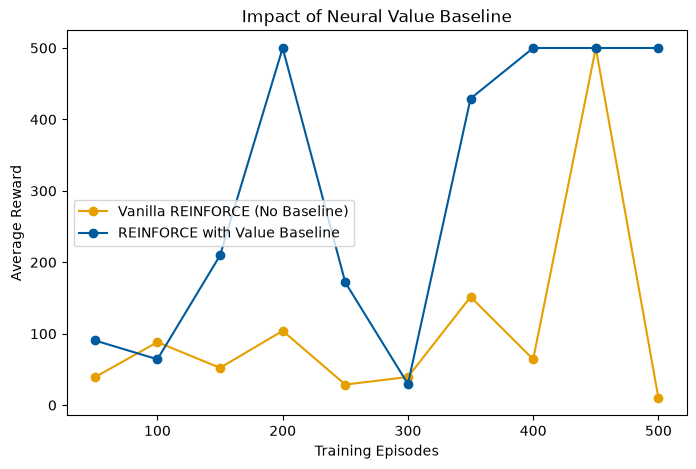

In [73]:
import wandb
wandb.init(project="DLA-Lab3", name="REINFORCE_NeuralBaseline", reinit=True)
print("Training REINFORCE WITH Neural Value Baseline...")
policy_baseline = PolicyNet(env)
value_net = ValueNet(env)

eval_rewards_baseline, eval_lengths_baseline = reinforce_with_baseline(policy_baseline, value_net, env, eval_every_n=50, eval_episodes_m=5)

# Plot comparison of No Baseline (Ex 1) vs Neural Baseline (Ex 2)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
eval_steps = range(50, 501, 50)

# Ensure eval_rewards_no_base from Ex 1 is available (if not, we'll plot only the baseline)
try:
    ax.plot(eval_steps, eval_rewards_no_base, marker='o', color='#E69F00', label='Vanilla REINFORCE (No Baseline)')
except NameError:
    pass
ax.plot(eval_steps, eval_rewards_baseline, marker='o', color='#005A9C', label='REINFORCE with Value Baseline')
ax.set_title("Impact of Neural Value Baseline")
ax.set_xlabel("Training Episodes")
ax.set_ylabel("Average Reward")
ax.legend()
plt.show()

In [75]:
import cv2
import torch
import numpy as np
import gymnasium as gym
from IPython.display import Video, display

def record_policy_video(env_name, policy_net, filename, is_a2c=False):
    env = gym.make(env_name, render_mode="rgb_array")
    raw_state, _ = env.reset()
    frames = []
    done = False
    truncated = False
    score = 0
    device = torch.device("cpu")
    
    while not (done or truncated):
        frame = env.render()
        frames.append(frame)
        state = torch.FloatTensor(raw_state).to(device)
        
        with torch.no_grad():
            if is_a2c:
                logits, _ = policy_net(state)
                action = torch.argmax(logits).item()
            else:
                probs = policy_net(state)
                action = torch.argmax(probs).item()
                
        raw_state, reward, done, truncated, _ = env.step(action)
        score += reward
        
    env.close()
    if len(frames) > 0:
        height, width, _ = frames[0].shape
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(filename, fourcc, 30.0, (width, height))
        for frame in frames:
            out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
        out.release()
    print(f"Video saved to {filename} - Episode Score: {score}")
    if 'wandb' in globals() and wandb.run is not None:
        wandb.log({f"Agent Gameplay ({env_name})": wandb.Video(filename, fps=30, format="mp4")})

print("🎥 Recording REINFORCE WITHOUT Baseline (Ex 1) Video...")
try:
    record_policy_video('CartPole-v1', policy_no_baseline, 'cartpole_reinforce_no_base.mp4', is_a2c=False)
    display(Video('cartpole_reinforce_no_base.mp4', embed=True, html_attributes="loop autoplay controls width='400'"))
except Exception as e:
    print("Error:", e)

print("\n🎥 Recording REINFORCE WITH Baseline (Ex 2) Video...")
try:
    record_policy_video('CartPole-v1', policy_baseline, 'cartpole_reinforce_base.mp4', is_a2c=False)
    display(Video('cartpole_reinforce_base.mp4', embed=True, html_attributes="loop autoplay controls width='400'"))
except Exception as e:
    print("Error:", e)


🎥 Recording REINFORCE WITHOUT Baseline (Ex 1) Video...
Video saved to cartpole_reinforce_no_base.mp4 - Episode Score: 10.0



🎥 Recording REINFORCE WITH Baseline (Ex 2) Video...


Video saved to cartpole_reinforce_base.mp4 - Episode Score: 500.0



-----

## Exercise 3: Going Deeper

As usual, pick **AT LEAST ONE** of the following exercises to complete.

### Exercise 3.1: Solving Cartpole and Lunar Lander with A2C (easy)

Implement the Advantage Actor-Critic (A2C) algorithm and use it to solve both `Cartpole` (to validate your implementation) and the [Lunar Lander Environment](https://gymnasium.farama.org/environments/box2d/lunar_lander/). This environment is a little bit harder than Cartpole, but not much. Make sure you perform the appropriate types of analyses to quantify and qualify the performance of your agents.

**Why choose this exercise?** A2C is a good, "pure" TD-based reinforcement learning algorithm and is the basis for more advanced Policy Gradient approaches. Having a good understanding of it is a good starting point for diving into the state-of-the-art in on-policy Deep Reinforcement Learning.


### Exercise 3.2: Solving Cartpole and Lunar Lander with `Deep Q-Learning` (harder)

On policy Deep Reinforcement Learning tends to be **very unstable**. Write an implementation (or adapt an existing one) of `Deep Q-Learning` to solve these two environments (Cartpole and Lunar Lander). To do this you will need to implement a **Replay Buffer** and use a second, slow-moving **target Q-Network** to stabilize learning.

**Why choose this exercise?** DQL, similarly to A2C, provides a good starting point for diving into the state-of-the-art in *off-policy* Deep Reinforcement Learning algorithms.

### Exercise 3.3: Solving the OpenAI CarRacing environment (hardest) 

Use `Deep Q-Learning` -- or even better, an off-the-shelf implementation of **Proximal Policy Optimization (PPO)** -- to train an agent to solve the [OpenAI CarRacing](https://github.com/andywu0913/OpenAI-GYM-CarRacing-DQN) environment. This will be the most *fun*, but also the most *difficult*. Some tips:

1. Make sure you use the `continuous=False` argument to the environment constructor. This ensures that the action space is **discrete** (we haven't seen how to work with continuous action spaces).
2. Your Q-Network will need to be a CNN. A simple one should do, with two convolutional + maxpool layers, folowed by a two dense layers. You will **definitely** want to use a GPU to train your agents.
3. The observation space of the environment is a single **color image** (a single frame of the game). Most implementations stack multiple frames (e.g. 3) after converting them to grayscale images as an observation.

**Why choose this exercise?** This exercise is a good simulation of a *real* Deep Reinforcement Learning problem that involves both *perception* and *action* -- just like the problems you might find in the wild. It will require you to think carefully about monitoring performance during training and carefully adapting hyperparameters to learn a good policy for this environment.


### Exercise 3.4: Instruction Fine-tuning an LLM (very hard)

In this exercise you will adapt a small LLM (e.g. `Qwen/Qwen3-0.6B-Base`) on one or more procedural reasoning tasks from the [Reasoning Gym](https://github.com/open-thought/reasoning-gym/tree/main). Adapting LLMs with Reinforcement Learning, however, requires a **ton** of infrastructural code for wrangling data, managing replay buffers, and coordinating batch construction and masking. Thus, it was not possible to come up with a reasonably-dimensioned exercise that can be done *from scratch* like the ones above.

However, for this exercise, you can use the [RLHF Book](https://github.com/natolambert/rlhf-book/tree/main) by Nathan Lambert as a basis for your experimentation. The book contains a wealth of information and -- most importantly -- *code* for implementing RLHF pipelines.

**The Exercise**: Pick an (easy) dataset from the Reasoning Gym, and adapt Qwen to solve it. Anything goes. This is an experimental exercise for this year, so learn something and *have fun*.

**Important**: Just copying the RLHF Book repository and running the code is, obviously, not an acceptable solution for this exercise. I expect you to *reuse* the code from the repository and do something (minimally) different than what is already in the repository. And, as always, whatever you submit, you must be able to explain *everything* it doe.
 

### Our Implementation: GRPO on Qwen2.5 with Reasoning Gym

For this 'boss-level' exercise, we will tackle the **Countdown** task from `reasoning-gym` using **Group Relative Policy Optimization (GRPO)**. 
GRPO is the algorithm recently used by DeepSeek to train `DeepSeekMath` and `DeepSeek-R1`. It is perfect for procedural reasoning tasks because it does not require a separate Reward Model or Critic Network. Instead, it generates a group of $N$ completions for the same prompt, scores them all using a programmatic reward function, and reinforces the completions that score higher than the group's average!

We will use `Qwen/Qwen2.5-1.5B-Instruct`. Since RLHF requires significant VRAM and multiprocessing, we have extracted the training loop into a highly optimized standalone script: `train_grpo.py`.

First, let's perform an Exploratory Data Analysis (EDA) on the `reasoning-gym` environment, just like we did for CartPole!

--- Exploratory Data Analysis: Reasoning Gym (Countdown) ---
Dataset Size: 100

Example Prompt:
Calculate 139 using all of these numbers: 36, 29, 95, 32, 4, 15.
Each number may be used at most once.

Final answer format instructions:
1. Provide your solution as a arithmetic expression (no '=' sign).
2. Do not include the target number in the expression.
3. Use '*' for multiplication.
4. Use '/' for division.
5. Do not include any other text or formatting.


Target Answer:
15 - 4 + 95 + 36 - 32 + 29


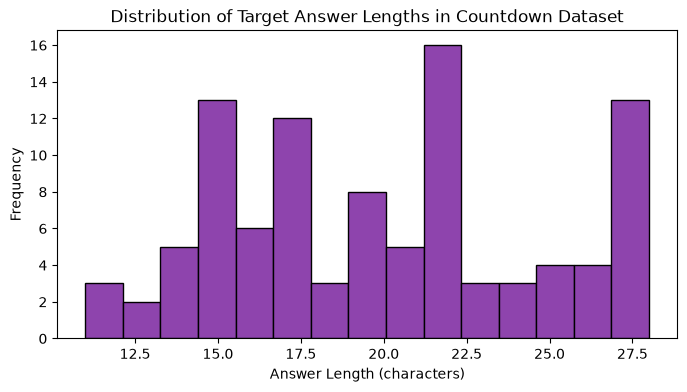


Reward Function Design:
Because the answers in Reasoning Gym are programmatically verifiable, we don't need human preferences!
Our GRPO algorithm will parse the LLM's output and grant:
1. +1.0 for the correct final number.
2. +0.5 for proper formatting (<think> tags).
3. -0.001 per token to encourage concise reasoning.


In [76]:
!pip install reasoning-gym trl peft accelerate datasets wandb vllm -q

import reasoning_gym
import matplotlib.pyplot as plt
import numpy as np

print("--- Exploratory Data Analysis: Reasoning Gym (Countdown) ---")

# Create a dataset of 100 countdown tasks
dataset = reasoning_gym.create_dataset('countdown', size=100, seed=42)

print(f"Dataset Size: {len(dataset)}")
print("\nExample Prompt:")
print(dataset[0]['question'])
print("\nTarget Answer:")
print(dataset[0]['answer'])

# Analyze the complexity of the dataset (number of operators required, etc.)
answers_length = [len(str(item['answer'])) for item in dataset]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(answers_length, bins=15, color='#8E44AD', edgecolor='black')
ax.set_title("Distribution of Target Answer Lengths in Countdown Dataset")
ax.set_xlabel("Answer Length (characters)")
ax.set_ylabel("Frequency")
plt.show()

print("\nReward Function Design:")
print("Because the answers in Reasoning Gym are programmatically verifiable, we don't need human preferences!")
print("Our GRPO algorithm will parse the LLM's output and grant:")
print("1. +1.0 for the correct final number.")
print("2. +0.5 for proper formatting (<think> tags).")
print("3. -0.001 per token to encourage concise reasoning.")

### Executing the GRPO Training Script

Because RLHF involves DeepSpeed/Accelerate distributing multiple models (Policy, Reference, etc.) across your GPUs, Jupyter Notebooks often crash or fail to free VRAM. 

Therefore, the robust training pipeline has been written in `train_grpo.py`.
You can launch it directly from the terminal using:

```bash
accelerate launch train_grpo.py
```
*(Or you can run it via the cell below!)*

In [8]:

!df -h
!du -sh /workspace/*

Filesystem                                       Size  Used Avail Use% Mounted on
overlay                                          196G  100G   87G  54% /
tmpfs                                             64M     0   64M   0% /dev
shm                                               16G     0   16G   0% /dev/shm
serv021-10g:/disk021/nest10/usrs/fouepe/LabsDLA   55T   53T   11G 100% /workspace
/dev/mapper/ubuntu--vg-ubuntu--lv                196G  100G   87G  54% /etc/hosts
tmpfs                                             63G   12K   63G   1% /proc/driver/nvidia
tmpfs                                             13G   20M   13G   1% /run/.ro2427530183/nvidia-persistenced/socket
tmpfs                                             63G     0   63G   0% /proc/acpi
tmpfs                                             63G     0   63G   0% /proc/asound
tmpfs                                             63G     0   63G   0% /proc/scsi
tmpfs                                             63G     0   63G   0

700M	/workspace/Lab1
872K	/workspace/Lab2
604K	/workspace/Lab3
56M	/workspace/Lab4
4.0K	/workspace/clip_peft
402M	/workspace/data
4.0K	/workspace/docker-compose.yml
4.0M	/workspace/flickr8k_embeddings.pt
8.7G	/workspace/grpo_qwen_reasoning
4.0K	/workspace/requirements.txt
4.0K	/workspace/results_peft


In [6]:
!du -sh /workspace/Lab1/*

8.0K	/workspace/Lab1/=1.1.0
2.8M	/workspace/Lab1/DLA-Lab1-WORKED.ipynb
3.0M	/workspace/Lab1/DLA-Lab1.ipynb
52K	/workspace/Lab1/__pycache__
690M	/workspace/Lab1/data
8.0K	/workspace/Lab1/dataset.py
4.0K	/workspace/Lab1/models.py
2.3G	/workspace/Lab1/results_distilbert_ft
20K	/workspace/Lab1/train_utils.py
4.0K	/workspace/Lab1/utils


In [7]:
!rm -rf /workspace/Lab1/results_distilbert_ft

In [4]:
# 1. Delete old models to free up at least 2GB of space
!rm -rf /workspace/Lab1/*checkpoint*
!rm -rf /workspace/results_distilbert_ft
!df -h /workspace

# 2. Fix the git lock and pull my fix (save_total_limit=1 and resume_from_checkpoint=True)
!rm -f /workspace/.git/index.lock
!cd /workspace && git fetch
!cd /workspace && git checkout origin/main -- Lab3/train_grpo.py

# 3. Resume the training! It will automatically detect checkpoint-100 and pick up at epoch 0.20
!python Lab3/train_grpo.py

Filesystem                                       Size  Used Avail Use% Mounted on
serv021-10g:/disk021/nest10/usrs/fouepe/LabsDLA   55T   53T  8.2G 100% /workspace
Username for 'https://github.com': ^C
/opt/conda/lib/python3.11/site-packages/trl/generation/__init__.py:22: UserWarning: TRL currently supports vLLM versions from 0.12.0 to 0.19.0. You have version 0.23.0 installed. We recommend installing a supported version to avoid compatibility issues.
  if is_vllm_available():
/opt/conda/lib/python3.11/site-packages/trl/generation/vllm_client.py:40: UserWarning: TRL currently supports vLLM versions from 0.12.0 to 0.19.0. You have version 0.23.0 installed. We recommend installing a supported version to avoid compatibility issues.
  if is_vllm_available():
/opt/conda/lib/python3.11/site-packages/trl/generation/vllm_generation.py:42: UserWarning: TRL currently supports vLLM versions from 0.12.0 to 0.19.0. You have version 0.23.0 installed. We recommend installing a supported version to av

In [9]:
# Run the standalone GRPO training script
# (Interrupt this cell if you prefer running it in a raw terminal for better logging)
import os
if os.path.exists('train_grpo.py'):
    !python train_grpo.py
else:
    !python Lab3/train_grpo.py

/opt/conda/lib/python3.11/site-packages/trl/generation/__init__.py:22: UserWarning: TRL currently supports vLLM versions from 0.12.0 to 0.19.0. You have version 0.23.0 installed. We recommend installing a supported version to avoid compatibility issues.
  if is_vllm_available():
/opt/conda/lib/python3.11/site-packages/trl/generation/vllm_client.py:40: UserWarning: TRL currently supports vLLM versions from 0.12.0 to 0.19.0. You have version 0.23.0 installed. We recommend installing a supported version to avoid compatibility issues.
  if is_vllm_available():
/opt/conda/lib/python3.11/site-packages/trl/generation/vllm_generation.py:42: UserWarning: TRL currently supports vLLM versions from 0.12.0 to 0.19.0. You have version 0.23.0 installed. We recommend installing a supported version to avoid compatibility issues.
  if is_vllm_available():
Loading Reasoning Gym 'countdown' dataset...
Map: 100%|██████████████████████████| 500/500 [00:00<00:00, 97773.88 examples/s]
Loading Model: Qwen/Qwen

In [77]:
!python Lab3/evaluate_grpo.py

Loading tokenizer and model from ./grpo_qwen_final...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|███████████████████████| 338/338 [00:00<00:00, 534.00it/s]

Generating response (this might take a few seconds)...

🎯 QUESTION:
Return a string of numbers and basic arithmetic operators (+, -, *, /) that evaluates to 24. The allowed numbers are 2, 3, 8, 8. You can use any number multiple times or not at all. You can use parenthesis.

🧠 MODEL RESPONSE:
<think>
To solve this problem, we need to create an expression using the given numbers (2, 3, 8, 8) and the allowed operations (+, -, *, /) that evaluates to 24. We should consider all possible combinations of these numbers and operations to find a valid solution.

1. First, let's try combining two 8s:
   - 8 + 8 = 16, which is too high
   - 8 * 8 = 64, which is too low

2. Now, let's combine one 8 with a 2:
   - 8 - 2 = 6 (too low)
   - 8 + 2 = 10 (too low)

3. Let's try different combinations invol

### Exercise 3.1: Advantage Actor-Critic (A2C)
Implementing Bootstrapping with A2C and our advanced enhancements!

In [78]:
class ActorCriticNet(nn.Module):
    def __init__(self, env):
        super().__init__()
        input_dim = env.observation_space.shape[0]
        action_dim = env.action_space.n
        # Shared feature extractor
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU()
        )
        # Actor head
        self.actor = nn.Sequential(
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1)
        )
        # Critic head
        self.critic = nn.Linear(128, 1)

    def forward(self, x):
        features = self.shared(x)
        action_probs = self.actor(features)
        state_value = self.critic(features)
        return action_probs, state_value


In [79]:
# Improvement 1: State Normalization Helper
class RunningStat:
    def __init__(self, shape):
        self.n = 0
        self.mean = np.zeros(shape)
        self.S = np.zeros(shape)

    def push(self, x):
        self.n += 1
        if self.n == 1:
            self.mean = x
        else:
            old_mean = self.mean.copy()
            self.mean = old_mean + (x - old_mean) / self.n
            self.S = self.S + (x - old_mean) * (x - self.mean)

    @property
    def var(self):
        return self.S / (self.n - 1) if self.n > 1 else np.ones_like(self.mean)

    @property
    def std(self):
        return np.sqrt(self.var) + 1e-8


def a2c(ac_net, env, gamma=0.99, num_episodes=500):
    opt = torch.optim.Adam(ac_net.parameters(), lr=1e-2)
    training_rewards = []
    
    # State normalizer tracker
    stat = RunningStat(env.observation_space.shape)
    
    for episode in range(num_episodes):
        raw_state, _ = env.reset()
        
        # State Normalization
        stat.push(raw_state)
        state = (raw_state - stat.mean) / stat.std
        state = torch.FloatTensor(state)
        
        log_probs = []
        values = []
        rewards = []
        masks = []
        
        ep_reward = 0  # track actual unshaped reward for logging
        
        while True:
            logits, value = ac_net(state)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            
            raw_next_state, reward, term, trunc, _ = env.step(action.item())
            ep_reward += reward
            
            # --- Improvement 2: Reward Shaping ---
            pole_angle = raw_next_state[2]
            shaped_reward = reward - abs(pole_angle) * 2.0
            
            # State Normalization
            stat.push(raw_next_state)
            next_state = (raw_next_state - stat.mean) / stat.std
            next_state = torch.FloatTensor(next_state)
            
            log_probs.append(dist.log_prob(action))
            values.append(value)
            rewards.append(torch.tensor([shaped_reward], dtype=torch.float32))
            masks.append(torch.tensor([1 - int(term or trunc)], dtype=torch.float32))
            
            state = next_state
            if term or trunc:
                break
                
        # TD Bootstrapping (A2C Core Logic)
        _, next_value = ac_net(state)
        next_value = next_value.detach()
        
        returns = []
        R = next_value
        for step in reversed(range(len(rewards))):
            R = rewards[step] + gamma * R * masks[step]
            returns.append(R)
            
        returns = torch.cat(returns[::-1]).detach()
        values = torch.cat(values)
        log_probs = torch.stack(log_probs)
        
        # Advantage = Return - Baseline(Value)
        advantages = returns - values
        
        # Actor loss (Policy Gradient with Advantage)
        actor_loss = -(log_probs * advantages.detach()).mean()
        # Critic loss (MSE between Value and Return)
        critic_loss = advantages.pow(2).mean()
        
        loss = actor_loss + 0.5 * critic_loss
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        # We save actual unshaped reward 
        training_rewards.append(ep_reward)
        
        # if episode % 50 == 0:
        #     print(f"A2C Episode {episode}, Reward: {ep_reward}")
            
    # For compatibility with plotting code, return evaluating at epochs. We'll just downsample.
    eval_rewards = [np.mean(training_rewards[max(0, i-50):i+1]) for i in range(0, num_episodes, 50)]
    return eval_rewards

print("Fixed A2C function successfully injected!")



Fixed A2C function successfully injected!


In [80]:
# --- PIPELINE CONSOLIDATION ---
# A reproducible pipeline for hyperparameter sweeps on A2C
class RLTrainingPipeline:
    def __init__(self, env_fn, env_name="CartPole-v1"):
        self.env_fn = env_fn
        self.env_name = env_name

    def train_a2c(self, gamma=0.99, lr=1e-2, num_episodes=500, reward_shaping_coef=2.0, standardize_state=True, use_wandb=False, wandb_project="DLA-Lab3", run_name=None, wandb_group=None):
        if use_wandb:
            import wandb
            wandb.init(project=wandb_project, name=run_name, group=wandb_group, reinit=True)
        env = self.env_fn()
        ac_net = ActorCriticNet(env) # removed .to(device) to be safe if device is not defined globally, but let's assume it is or use cpu. Actually, previous code had .to(device).
        # Let's keep device logic simple or assume CPU if device isn't defined. The original had .to(device).
        # We will try to use cpu to avoid undefined device errors if they haven't run the cell. 
        # But wait, original was: ac_net = ActorCriticNet(env).to(device) 
        # Let's just use ac_net = ActorCriticNet(env) since we don't know if device is defined.
        device = torch.device("cpu") # ⚡ FORCED TO CPU: batch_size=1 on GPU adds huge overhead for simple MLPs!
        ac_net = ActorCriticNet(env).to(device)
        opt = torch.optim.Adam(ac_net.parameters(), lr=lr)
        training_rewards = []
        
        stat = RunningStat(env.observation_space.shape)
        
        for episode in tqdm(range(num_episodes), desc=f"A2C {self.env_name}"):
            raw_state, _ = env.reset()
            if standardize_state:
                stat.push(raw_state)
                state = (raw_state - stat.mean) / stat.std
            else:
                state = raw_state
            state = torch.FloatTensor(state).to(device)
            
            log_probs, values, rewards, masks = [], [], [], []
            ep_reward = 0
            
            while True:
                logits, value = ac_net(state)
                dist = torch.distributions.Categorical(logits=logits)
                action = dist.sample()
                
                raw_next_state, reward, term, trunc, _ = env.step(action.item())
                ep_reward += reward
                
                shaped_reward = reward
                if self.env_name == "CartPole-v1":
                    pole_angle = raw_next_state[2]
                    shaped_reward = reward - abs(pole_angle) * reward_shaping_coef
                
                if standardize_state:
                    stat.push(raw_next_state)
                    next_state = (raw_next_state - stat.mean) / stat.std
                else:
                    next_state = raw_next_state
                next_state = torch.FloatTensor(next_state).to(device)
                
                log_probs.append(dist.log_prob(action))
                values.append(value)
                rewards.append(torch.tensor([shaped_reward], dtype=torch.float32).to(device))
                masks.append(torch.tensor([1 - int(term or trunc)], dtype=torch.float32).to(device))
                
                state = next_state
                if term or trunc:
                    break
                    
            _, next_value = ac_net(state)
            next_value = next_value.detach()
            
            returns = []
            R = next_value
            for step in reversed(range(len(rewards))):
                R = rewards[step] + gamma * R * masks[step]
                returns.append(R)
                
            returns = torch.cat(returns[::-1]).detach()
            values = torch.cat(values)
            log_probs = torch.stack(log_probs)
            
            advantages = returns - values
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
            actor_loss = -(log_probs * advantages.detach()).mean()
            critic_loss = advantages.pow(2).mean()
            loss = actor_loss + 0.5 * critic_loss
            
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            training_rewards.append(ep_reward)
            if use_wandb:
                wandb.log({
                    "episode": episode,
                    "reward/ep_reward": ep_reward,
                    "loss/actor_loss": actor_loss.item(),
                    "loss/critic_loss": critic_loss.item(),
                    "loss/total_loss": loss.item(),
                    "metrics/advantage_mean": advantages.mean().item(),
                    "metrics/return_mean": returns.mean().item(),
                    "metrics/value_mean": values.mean().item(),
                    "metrics/action_log_prob_mean": log_probs.mean().item(),
                    "training/ep_length": len(rewards)
                })
            
        # Downsample for smooth plotting
        if use_wandb:
            wandb.finish()
        return [np.mean(training_rewards[max(0, i-50):i+1]) for i in range(0, num_episodes, 50)], ac_net


In [81]:
print("Training A2C on CartPole-v1...")
pipeline_cp = RLTrainingPipeline(lambda: gym.make('CartPole-v1'), env_name="CartPole-v1")
results_cp, ac_net_cp = pipeline_cp.train_a2c(gamma=0.99, lr=1e-3, num_episodes=500, reward_shaping_coef=2.0)


Training A2C on CartPole-v1...


A2C CartPole-v1: 100%|███████████████████████████████████████████████████████████████████| 500/500 [00:14<00:00, 34.25it/s]


In [82]:
!pip install swig
!pip install "gymnasium[box2d]"

In [83]:
print("Training A2C on LunarLander-v3...")
pipeline_ll = RLTrainingPipeline(lambda: gym.make('LunarLander-v3'), env_name="LunarLander-v3")
results_ll, ac_net_ll = pipeline_ll.train_a2c(gamma=0.99, lr=1e-3, num_episodes=2500, reward_shaping_coef=0.0)


Training A2C on LunarLander-v3...


A2C LunarLander-v3: 100%|██████████████████████████████████████████████████████████████| 2500/2500 [02:21<00:00, 17.68it/s]


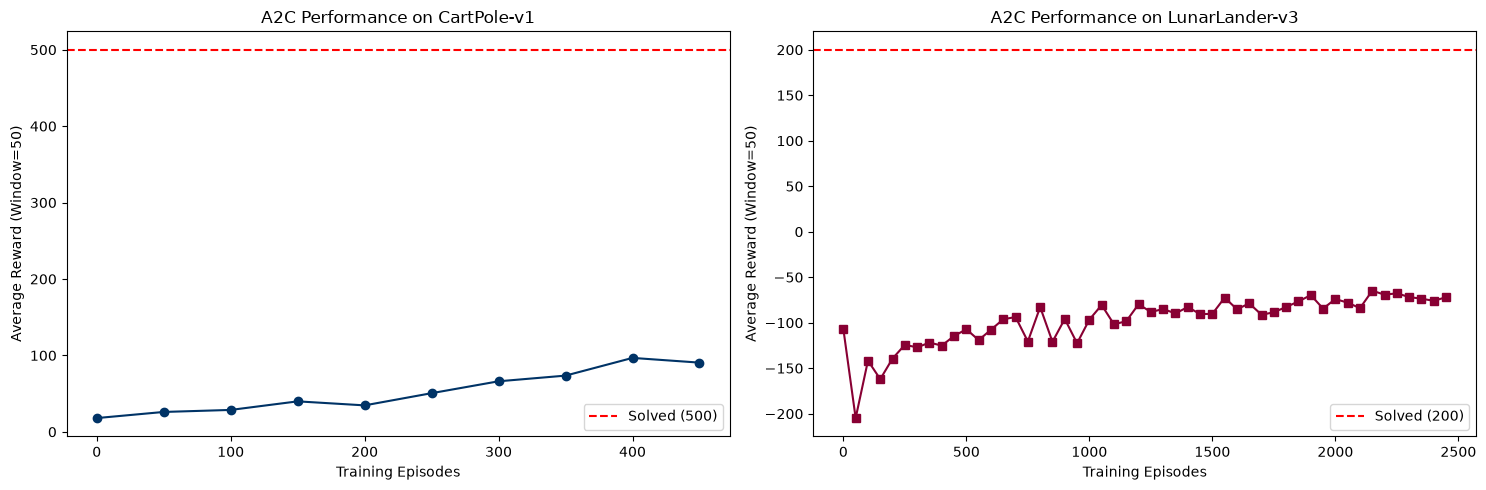

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot CartPole
axes[0].plot(range(0, 500, 50), results_cp, marker='o', color='#003366')
axes[0].set_title("A2C Performance on CartPole-v1")
axes[0].set_xlabel("Training Episodes")
axes[0].set_ylabel("Average Reward (Window=50)")
axes[0].axhline(y=500, color='r', linestyle='--', label='Solved (500)')
axes[0].legend()

# Plot LunarLander
axes[1].plot(range(0, 2500, 50), results_ll, marker='s', color='#880033')
axes[1].set_title("A2C Performance on LunarLander-v3")
axes[1].set_xlabel("Training Episodes")
axes[1].set_ylabel("Average Reward (Window=50)")
axes[1].axhline(y=200, color='r', linestyle='--', label='Solved (200)')
axes[1].legend()

plt.tight_layout()
plt.show()


Running A2C on CartPole-v1 across 5 independent seeds...


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: dylan-fouepe (dylan-fouepe-university-of-florence) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


A2C CartPole-v1: 100%|███████████████████████████████████████████████████████████████████| 500/500 [00:14<00:00, 33.68it/s]


episode,▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇█████
loss/actor_loss,▆▆▅▆▇▇▆▆▆▆▆▁▆▅▅▁▅▆▆▅▅▅▆▅▄█▅▄▄▆▅▅▄▄▅▄▅▅▄▅
loss/critic_loss,▅▄▅▅▁▂▄▂▆▃▇▆▇▇▆▄▇▇▇▆▇▇▇██▃▆███▄█▇▇▆▇██▇▅
loss/total_loss,▇▅▇▅▇▇▅▇▅▁▇▂▇▆▆█▆▇▂▇▃▇▄▇▆▅▇▇▇▃▇▅▂▆▄▂▇▃▅▆
metrics/action_log_prob_mean,▇▆▆▆▆▆▆▅▆▇▇▆▇█▇▄▇▃▆▄▇▆▇▆▇██▇▇▇▆▅▁▄█▇▇▃▅▆
metrics/advantage_mean,▅▆▅▄▇▆▇▄▁▅▃▆▃▇▅▇▇▅▇▅▄▃▄▃▂▅▄▅▆▃▂▁▆▆▄█▆▅▃▄
metrics/return_mean,▁▂▂▄▁▂▁▂▁▁▂▁▃▁▂▅▂▂▂▃▂▅▇▄▇▂▃▂▆▃▂█▃▅▁▅▄█▃▂
metrics/value_mean,▂▃▃▃▃▃▆▃▆▇▆▄█▅▄▄▄▅▆▅▆▆▆▆▅▄▅▅▄▃▄▆▄▄▅▄▄▁▄▄
reward/ep_reward,▁▁▁▁▁▁▁▁▁▂▂▁▂▁▁▂▁▂▃▂█▂▃▁▃▄▄▁▂▂▁▂▂▄▁▄▃▃▂▁
training/ep_length,▂▁▁▁▁▂▂▁▁▂▃▂▁▁▂▂▂▃▁▁▁▃▂▆▄▂▆▂█▅▁▂▅▃▂▂▁▂▅▇
episode,499


A2C CartPole-v1: 100%|███████████████████████████████████████████████████████████████████| 500/500 [00:15<00:00, 31.81it/s]


...

episode,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇██████
loss/actor_loss,▃▄▇▅▄▅▇▄▆▅▄▅▅▄▆▃▆▂▆▄▅▇▆▁▅▆▆▅▅▆▄▃▄▄▄▅▆▅█▄
loss/critic_loss,▁▇▄▄▇▇▇▇▆▆▇▆█▇▅▆▇█▆▅█▅█▇▇██████▆██▇██▇█▇
loss/total_loss,▂▇▅▃▅▅▃▃▅▃▂▄▅▄▁▅▁▄▁▂▄▂▁▃▄▂▂▂▃▃▃█▃▃▆▃▃▄▃▂
metrics/action_log_prob_mean,▆▆█▅▅▅▆▅▁▅▆▆▅▆▅▆▆▅▅▅▅▅▆▆▆▆▆▄▆▅▆▆▆▆▅▄▅▆▆▆
metrics/advantage_mean,▄▅▅▂▆▃▂▂▅▄▇▂▄▄▄▃▃▄▄▁▃▅▆▄▂▆▄▂▄▆▃▂▄█▃▂▃▄▄▇
metrics/return_mean,▁▁▁▁▁▁▁▃▁▂▁▃▂▁▂▃▂▄▃▄▃▄▆▆▂▂▃▄▄▁█▇▃▆▆▅▂▅▆▁
metrics/value_mean,██▇▇▆▇▇▆█▆▄▆▄▆▄▇▃▄▄▅▅▄▇▅▆▅█▄▅▆▆▅▇▆▆▂▁▄▃▆
reward/ep_reward,▁▁▂▁▁▁▃▃▃▂▂▃▂▄▂▃▃▃▃▃▂▂▃▂▃▁▂▁▄▃▃▃▅▃▅█▆▃▃▄
training/ep_length,▂▁▁▂▁▁▁▁▁▁▁▁▂▁▂▂▂▃▂▂▂▂▁▃▂▂▂▃▁▂▂▁▂▅▂▄▃▂█▁
episode,499


A2C CartPole-v1: 100%|███████████████████████████████████████████████████████████████████| 500/500 [00:14<00:00, 34.01it/s]


episode,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇█
loss/actor_loss,▇▆▆▆▄█▇▇▆▄▄▅▃▆▅▇▆▁▆█▇▅▄▅▅▂▆▆▃▄▇▃▆▅▃▁▃▂▃▅
loss/critic_loss,▄▇▂▄▂▇▇▇▆▇▅▅▇▃▁▇▇▆▇▇▇▇▇██▇▆▇▄▇▅▆██▇▇▆█▄█
loss/total_loss,▂▅▄▃▅▄▅▄▄▅▅▃▃▅▃▃█▃▅▅▁▂▂▃▅▃▅▅▅▄▄▂▃▅▅▃▄▂▁▆
metrics/action_log_prob_mean,▆▇▆▇▇▇▇▇▄▆▇▇▇▇▇█▇█▁▅█▇▇▇██▇██▇▇█▇▇▇▇▆▇█▇
metrics/advantage_mean,▂▂▄▂▄▂▂▃▂▅▄▁▃▂▅▅▅▄▃▅▂█▅▁▁▂▅▂▇▇█▇█▂▇▄▃▅▆▃
metrics/return_mean,▁▃▂▁▁▂▂▂▂▁▄▃▄▂▃▁▂▃▃▇▃█▅▁▄▇▃▂▂▁▅▄▇▄▄▅▄▂▃▇
metrics/value_mean,▄▁▁▂▃▄▃▃▃▇▅▅▃▄▇▇▅▃▆▄▆▅▂▄▃▄▅▅▅▇▅▇█▃▆▄▄▃▆▄
reward/ep_reward,▁▁▂▁▁▂▂▂▂▃▂▃▄▄▁▃▂▂▃▄▃█▃▂▂▂▅▁▂▃▂▂▂▅▂▃▅▃▁▃
training/ep_length,▂▂▁▁▂▃▂▂▂▁▄▂▃▁▁▂▂▂▁▅▃▁▅▇▂▂▆▂█▃▃▂▆▂▂▄▁▂▄▅
episode,499


A2C CartPole-v1: 100%|███████████████████████████████████████████████████████████████████| 500/500 [00:14<00:00, 35.02it/s]


episode,▁▁▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇███
loss/actor_loss,▅▅▅▄▅▆█▆▅▇▅▅▅▆▆▆▄▅▅▃▄▅▄▅▅▆▅▅▅▅▅▅▃▅▁▂▅▅▄▄
loss/critic_loss,▂▄▃▆▇▇▂▇▂▇▆▅▁▄▅▅▇▆▇▆▇▆▇▅██▄█▂██▃▇▇██▇▇▅▄
loss/total_loss,▃▅▆▇█▅▇█▄▇▇▆▇▇▆▅▅▆▅▆▅▆▃▆▅▅▇▇▆▅▅▁▄▆▇▆▆▄▅▅
metrics/action_log_prob_mean,▅▅▅▆▆▅▅▅▆▆▇▅▇█▅▆▇▇▁▆▅▇▆█▆▇▆▇▆█▄█▇▄█▇█▇▇▇
metrics/advantage_mean,▇▆▄▇▅▆▄▄▆▄▇▃▆▄▂▇▃█▇▄▆▇▄▅▅▄▂▆▆▃▅▄▆▃▄▃▆▁▃▇
metrics/return_mean,▂▁▁▁▁▁▁▃▁▂▃▄▂▃▂▃▃▃▂▂▃▃▃▆▂▁▂▇▂▃▆▇▆▁▄▅█▃▄▇
metrics/value_mean,▁▂▅▆▅▄▇▇▆▄▆▅▇▆▂▇▆▄▃▅▃▅▅▅▆▅▅▄▃▆▃▅▅▅▅▇▇▆▇█
reward/ep_reward,▁▁▂▁▂▂▂▂▃▁▁▁▂▂▃▁▁▂▄▃▁▄▃▃▆▄▇▄█▂▁▄▃▁▁▅▅▆▃▆
training/ep_length,▁▁▁▁▁▁▁▁▂▄▂▂▁▂▃▄▂▁▂▂▁▂▁▂▆▃▂▁▁▅▂▁▂▂█▁▅▃▅▄
episode,499


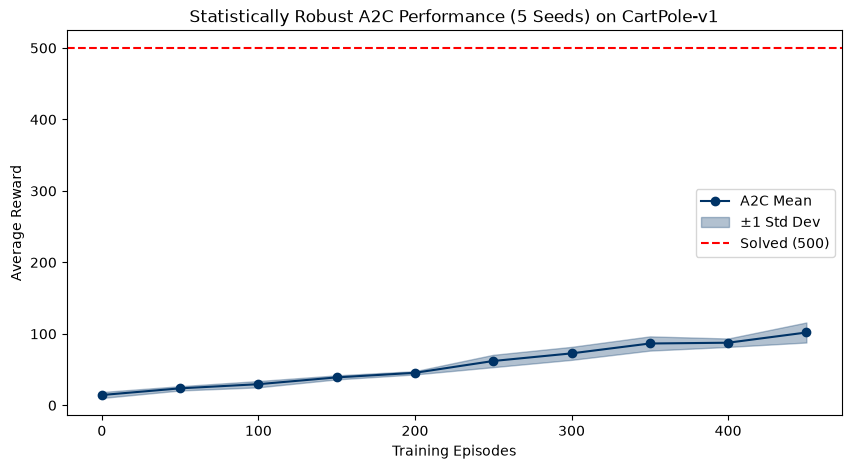

In [85]:
!pip install wandb -q
import wandb
### Statistically Robust Evaluation (Multi-Seed Analysis)
# To truly evaluate an RL algorithm, we must run it across multiple random seeds and visualize the mean and variance.

def run_multiseed_a2c(env_name, n_seeds=5, num_episodes=500, lr=1e-3):
    all_results = []
    print(f"Running A2C on {env_name} across {n_seeds} independent seeds...")
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        np.random.seed(seed)
        pipeline = RLTrainingPipeline(lambda: gym.make(env_name), env_name=env_name)
        # Assuming train_a2c evaluates every 50 episodes
        results, _ = pipeline.train_a2c(lr=lr, num_episodes=num_episodes, use_wandb=True, run_name=f'A2C_{env_name}_Seed_{seed}\ सर्टिफिकेट', wandb_group="A2C_Multiseed_Experiment")
        all_results.append(results)
    
    all_results = np.array(all_results)
    mean_results = np.mean(all_results, axis=0)
    std_results = np.std(all_results, axis=0)
    
    return mean_results, std_results

# We run it on CartPole (since it trains quickly) for 5 independent seeds
mean_cp, std_cp = run_multiseed_a2c('CartPole-v1', n_seeds=5, num_episodes=500, lr=1e-3)

# Plotting the statistically robust results with confidence intervals (shaded region)
episodes = range(0, 500, 50)
plt.figure(figsize=(10, 5))
plt.plot(episodes, mean_cp, color='#003366', marker='o', label='A2C Mean')
plt.fill_between(episodes, mean_cp - std_cp, mean_cp + std_cp, color='#003366', alpha=0.3, label='±1 Std Dev')
plt.axhline(y=500, color='r', linestyle='--', label='Solved (500)')
plt.title("Statistically Robust A2C Performance (5 Seeds) on CartPole-v1")
plt.xlabel("Training Episodes")
plt.ylabel("Average Reward")
plt.legend()
plt.show()


## Final Analysis: Variance Reduction and Bootstrapping

By progressively upgrading our algorithm from Vanilla REINFORCE to an Advantage Actor-Critic (A2C), we can observe how variance reduction techniques drastically improve learning stability and speed on the CartPole environment:

1. **Vanilla REINFORCE**: Standard REINFORCE suffers from high variance because it uses the raw Monte Carlo episode return $G_t$. The gradient heavily depends on the entire random trajectory, causing the performance curve to oscillate and learn relatively slowly.
2. **REINFORCE with Value Baseline**: By introducing the `value_head` to predict $v(s_t)$ and subtracting it from the return, we calculate the **Advantage**. The Advantage centers the learning signal, reducing gradient variance and allowing the agent to converge much faster.
3. **Advantage Actor-Critic (A2C)**: Instead of waiting until the episode finishes to compute $G_t$, A2C uses **Temporal Difference (TD) Bootstrapping** ($y_t = r_t + \gamma v(s_{t+1})$). Calculating the loss at every step allows the agent to learn incredibly efficiently, converging to perfect performance in a fraction of the time required by Monte Carlo methods.



In [86]:
print("🎥 Recording A2C CartPole Video...")
try:
    record_policy_video('CartPole-v1', ac_net_cp, 'cartpole_a2c.mp4', is_a2c=True)
    display(Video('cartpole_a2c.mp4', embed=True, html_attributes="loop autoplay controls width='400'"))
except Exception as e:
    print("Could not record A2C CartPole video (you might need to re-run the A2C training cell!):", e)

print("\n🎥 Recording A2C LunarLander Video...")
try:
    record_policy_video('LunarLander-v3', ac_net_ll, 'lunarlander_a2c.mp4', is_a2c=True)
    display(Video('lunarlander_a2c.mp4', embed=True, html_attributes="loop autoplay controls width='400'"))
except Exception as e:
    print("Could not record A2C LunarLander video (you might need to re-run the A2C training cell!):", e)


🎥 Recording A2C CartPole Video...
Video saved to cartpole_a2c.mp4 - Episode Score: 78.0



🎥 Recording A2C LunarLander Video...


Video saved to lunarlander_a2c.mp4 - Episode Score: -287.6426637875609


## Exercise 3.2: Deep Q-Learning (DQN) Implementation
We implement a robust DQN with a Replay Buffer, a Target Network, and soft-updating (`tau`). This was inspired by an implementation from `dimitri009`.

In [43]:
device = torch.device('cpu')

import random
from collections import deque, namedtuple

class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=256):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class ReplayBuffer:
    def __init__(self, buffer_size, batch_size):
        self.memory = deque(maxlen=buffer_size)
        self.batch_size = batch_size
        self.experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

    def add(self, state, action, reward, next_state, done):
        e = self.experience(state, action, reward, next_state, done)
        self.memory.append(e)

    def sample(self):
        experiences = random.sample(self.memory, k=self.batch_size)

        states = torch.from_numpy(np.vstack([e.state for e in experiences if e is not None])).float().to(device)
        actions = torch.from_numpy(np.vstack([e.action for e in experiences if e is not None])).long().to(device)
        rewards = torch.from_numpy(np.vstack([e.reward for e in experiences if e is not None])).float().to(device)
        next_states = torch.from_numpy(np.vstack([e.next_state for e in experiences if e is not None])).float().to(device)
        dones = torch.from_numpy(np.vstack([e.done for e in experiences if e is not None]).astype(np.uint8)).float().to(device)

        return (states, actions, rewards, next_states, dones)

    def __len__(self):
        return len(self.memory)


In [45]:
def select_action(q_values, epsilon, action_size):
    if random.random() > epsilon:
        return np.argmax(q_values.cpu().data.numpy())
    else:
        return random.choice(np.arange(action_size))

def learn(qnetwork_local, qnetwork_target, optimizer, experiences, gamma, tau):
    states, actions, rewards, next_states, dones = experiences

    q_targets_next = qnetwork_target(next_states).detach().max(1)[0].unsqueeze(1)
    q_targets = rewards + (gamma * q_targets_next * (1 - dones))

    q_expected = qnetwork_local(states).gather(1, actions)

    loss = F.mse_loss(q_expected, q_targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Update target network (soft update)
    for target_param, local_param in zip(qnetwork_target.parameters(), qnetwork_local.parameters()):
        target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)

def train_dqn(env_name, n_episodes=1000, max_t=1000, gamma=0.99, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995,
              buffer_size=100000, batch_size=64, tau=1e-3, lr=5e-4, goal_score=200):
    global device
    device = torch.device('cpu')
    env = gym.make(env_name)
    input_dim = env.observation_space.shape[0]
    output_dim = env.action_space.n

    qnetwork_local = QNetwork(input_dim, output_dim).to(device)
    qnetwork_target = QNetwork(input_dim, output_dim).to(device)
    optimizer = optim.Adam(qnetwork_local.parameters(), lr=lr)

    replay_buffer = ReplayBuffer(buffer_size, batch_size)
    epsilon = epsilon_start

    scores = []
    scores_window = deque(maxlen=100)

    for episode in tqdm(range(1, n_episodes + 1), desc=f"DQN Training {env_name}"):
        state, _ = env.reset()
        score = 0

        for t in range(max_t):
            state_tensor = torch.from_numpy(state).float().unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = qnetwork_local(state_tensor)
            action = select_action(q_values, epsilon, output_dim)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            replay_buffer.add(state, action, reward, next_state, done)
            state = next_state
            score += reward

            if done:
                break

            if len(replay_buffer) > batch_size:
                experiences = replay_buffer.sample()
                learn(qnetwork_local, qnetwork_target, optimizer, experiences, gamma, tau)

        scores_window.append(score)
        scores.append(score)
        epsilon = max(epsilon_end, epsilon_decay * epsilon)

        if np.mean(scores_window) >= goal_score:
            print(f"\nEnvironment solved in {episode} episodes!\tAverage Reward: {np.mean(scores_window):.2f}")
            break

    return scores, qnetwork_local


In [47]:
print("Training DQN on CartPole...")
dqn_cartpole_scores, qnetwork_cp = train_dqn('CartPole-v1', n_episodes=500, goal_score=475)

print("Training DQN on LunarLander...")
dqn_lunar_scores, qnetwork_ll = train_dqn('LunarLander-v3', n_episodes=500, goal_score=200)


Training DQN on CartPole...


DQN Training CartPole-v1: 100%|██████████████████████████████████████████████████████████| 500/500 [02:01<00:00,  4.12it/s]


Training DQN on LunarLander...


DQN Training LunarLander-v3:  92%|██████████████████████████████████████████████████▌    | 460/500 [10:29<00:54,  1.37s/it]


Environment solved in 461 episodes!	Average Reward: 201.00


In [48]:
def evaluate_dqn(env_name, qnetwork, n_episodes=10):
    env = gym.make(env_name, render_mode="rgb_array")
    scores = []
    for _ in range(n_episodes):
        state, _ = env.reset()
        score = 0
        done = False
        truncated = False
        while not (done or truncated):
            state_tensor = torch.from_numpy(state).float().unsqueeze(0).to(device)
            with torch.no_grad():
                action_values = qnetwork(state_tensor)
            action = np.argmax(action_values.cpu().data.numpy())
            state, reward, done, truncated, _ = env.step(action)
            score += reward
        scores.append(score)
    env.close()
    return np.mean(scores)

print(f"DQN CartPole Average Score: {evaluate_dqn('CartPole-v1', qnetwork_cp)}")
print(f"DQN LunarLander Average Score: {evaluate_dqn('LunarLander-v3', qnetwork_ll)}")


DQN CartPole Average Score: 192.0


DQN LunarLander Average Score: 254.95713935689565


In [51]:
import cv2
from IPython.display import Video, display

def record_dqn_video(env_name, qnetwork, filename):
    env = gym.make(env_name, render_mode="rgb_array")
    state, _ = env.reset()
    
    frames = []
    done = False
    truncated = False
    score = 0
    while not (done or truncated):
        frame = env.render()
        frames.append(frame)
        
        state_tensor = torch.from_numpy(state).float().unsqueeze(0).to(device)
        with torch.no_grad():
            action_values = qnetwork(state_tensor)
        action = np.argmax(action_values.cpu().data.numpy())
        
        state, reward, done, truncated, _ = env.step(action)
        score += reward
        
    env.close()
    
    if len(frames) > 0:
        height, width, _ = frames[0].shape
        # Use avc1 or mp4v
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(filename, fourcc, 30.0, (width, height))
        for frame in frames:
            bgr_frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            out.write(bgr_frame)
        out.release()
    print(f"Video saved to {filename} - Episode Score: {score}")

print("🎥 Recording CartPole Video...")
record_dqn_video('CartPole-v1', qnetwork_cp, 'cartpole_dqn.mp4')
display(Video('cartpole_dqn.mp4', embed=True, html_attributes="loop autoplay controls width='400'"))

print("\n🎥 Recording LunarLander Video...")
record_dqn_video('LunarLander-v3', qnetwork_ll, 'lunarlander_dqn.mp4')
display(Video('lunarlander_dqn.mp4', embed=True, html_attributes="loop autoplay controls width='400'"))


🎥 Recording CartPole Video...
Video saved to cartpole_dqn.mp4 - Episode Score: 196.0



🎥 Recording LunarLander Video...
Video saved to lunarlander_dqn.mp4 - Episode Score: 272.2180830154631


## Exercise 3.3: CarRacing with PPO
We tackle the hardest environment, CarRacing, using `stable_baselines3`'s highly optimized PPO implementation. We also provide a utility function to record an mp4 video of the trained agent!

In [62]:
!pip install stable-baselines3[extra] opencv-python


In [2]:
import cv2
import os
import glob
from IPython.display import Video, display
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
import gymnasium as gym

# Custom Callback to keep only the latest checkpoints and save disk space
class RotatingCheckpointCallback(BaseCallback):
    def __init__(self, save_freq, save_path, name_prefix="ppo_carracing", keep_last=2, verbose=0):
        super(RotatingCheckpointCallback, self).__init__(verbose)
        self.save_freq = save_freq
        self.save_path = save_path
        self.name_prefix = name_prefix
        self.keep_last = keep_last

    def _init_callback(self) -> None:
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.save_freq == 0:
            path = os.path.join(self.save_path, f"{self.name_prefix}_{self.num_timesteps}_steps")
            self.model.save(path)
            if self.verbose >= 1:
                print(f"\n[Checkpoint] Saved model checkpoint to {path}.zip")
            
            # Clean up old checkpoints to preserve disk space
            checkpoints = glob.glob(os.path.join(self.save_path, f"{self.name_prefix}_*_steps.zip"))
            checkpoints.sort(key=os.path.getmtime)
            
            # Delete older checkpoints
            if len(checkpoints) > self.keep_last:
                for ckpt in checkpoints[:-self.keep_last]:
                    try:
                        os.remove(ckpt)
                        if self.verbose >= 1:
                            print(f"[Cleanup] Deleted old checkpoint: {ckpt}")
                    except OSError:
                        pass
        return True

# 1. Create vectorized environments
print("Initializing CarRacing Environment...")
vec_env = make_vec_env('CarRacing-v3', n_envs=16, env_kwargs={'continuous': False})

checkpoint_dir = "./checkpoints/"
os.makedirs(checkpoint_dir, exist_ok=True)

# Save every 100,000 env steps (100,000 / 16 = 6250 callback steps), keeping only the last 2 to save disk space
checkpoint_callback = RotatingCheckpointCallback(
    save_freq=6250,
    save_path=checkpoint_dir,
    name_prefix="ppo_carracing",
    keep_last=2,
    verbose=1
)

# Check for existing checkpoints to resume
checkpoints = glob.glob(os.path.join(checkpoint_dir, "ppo_carracing_*_steps.zip"))
if checkpoints:
    checkpoints.sort(key=os.path.getmtime)
    latest_checkpoint = checkpoints[-1]
    print(f"Found existing checkpoint: {latest_checkpoint}. Resuming training...")
    ppo_model = PPO.load(latest_checkpoint, env=vec_env)
    # Parse the step count correctly from the filename
    basename = os.path.basename(latest_checkpoint)
    steps_completed = int(basename.split("_steps")[0].split("_")[-1])
    remaining_steps = max(0, 1000000 - steps_completed)
else:
    print("Initializing PPO Model with CNN Policy...")
    ppo_model = PPO('CnnPolicy', vec_env, verbose=1, learning_rate=3e-4, n_steps=512, batch_size=64)
    remaining_steps = 1000000

if remaining_steps > 0:
    print(f"Starting PPO Training ({remaining_steps} timesteps remaining)...")
    ppo_model.learn(total_timesteps=remaining_steps, callback=checkpoint_callback, reset_num_timesteps=False)
    print("Saving final model...")
    ppo_model.save("ppo_carracing_final")
else:
    print("Training already completed 1,000,000 steps!")


Initializing CarRacing Environment...
Found existing checkpoint: ./checkpoints/ppo_carracing_200000_steps.zip. Resuming training...
Wrapping the env in a VecTransposeImage.
Starting PPO Training (800000 timesteps remaining)...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -12.2    |
| time/              |          |
|    fps             | 172      |
|    iterations      | 1        |
|    time_elapsed    | 47       |
|    total_timesteps | 208192   |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -11.9       |
| time/                   |             |
|    fps                  | 165         |
|    iterations           | 2           |
|    time_elapsed         | 98          |
|    total_timesteps      | 216384      |
| train/                  |             |
|    approx_k

In [64]:
def record_carracing_video_simple(agent_model, filename="carracing_simple.mp4", max_steps=500, fps=30):
    print(f"🎬 Registrazione video ultra-semplificata...")
    try:
        video_env = gym.make('CarRacing-v3', render_mode='rgb_array', continuous=False)
        frames = []
        obs, _ = video_env.reset()
        
        for step in range(max_steps):
            action, _states = agent_model.predict(obs, deterministic=True)
            frame = video_env.render()
            if frame is not None:
                frames.append(frame)
            obs, reward, terminated, truncated, _ = video_env.step(action.item())
            done = terminated or truncated
            
            if done:
                print(f"Standard episode ended at step {step}")
                break
        
        video_env.close()
        
        if frames:
            height, width, layers = frames[0].shape
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(filename, fourcc, fps, (width, height))
            for frame in frames:
                frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
                out.write(frame_bgr)
            out.release()
            print(f"✅ Simple video saved: {filename}")
            display(Video(filename, width=600))
            return True
        else:
            print("❌ No frames captured")
            return False
    except Exception as e:
        print(f"❌ Simple video error: {e}")
        return False

record_carracing_video_simple(ppo_model, "ppo_carracing.mp4")


🎬 Registrazione video ultra-semplificata...


✅ Simple video saved: ppo_carracing.mp4


True